✓ Config imported successfully!
C:\Users\user


C:\Users\user\AppData\Local\Temp\ipykernel_2856\3164108343.py:22: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


 Total Rows : 2211
2077     0-2-5-0 Aana
883      0-7-0-0 Aana
511     1340 Sq. Feet
1505    3280 Sq. Feet
1162          20 Aana
Name: Area, dtype: object
Area
4 Aana          163
3 Aana           86
5 Aana           71
0-4-0-0 Aana     66
8 Aana           57
Name: count, dtype: int64
0
Duplicate rows found: 0
After dropping garbage: 2158 rows remaining
land_system
hill_system        1775
standard_system     263
terai_system         95
local_system         25
Name: count, dtype: int64
Empty DataFrame
Columns: [Area, value_raw, unit_raw, unit_clean, unit_final]
Index: []
unit_final
aana      1636
sqft       258
ropani     138
dhur        58
kattha      33
haat        25
sqm          5
bigha        4
paisa        1
Name: count, dtype: int64
Empty DataFrame
Columns: [Area, value_raw, unit_raw, unit_clean, unit_final]
Index: []
                Area value_raw unit_raw unit_clean unit_final
154       3 .5 Bigha       3.5    bigha      bigha      bigha
232          3 Bigha         3    bigha 

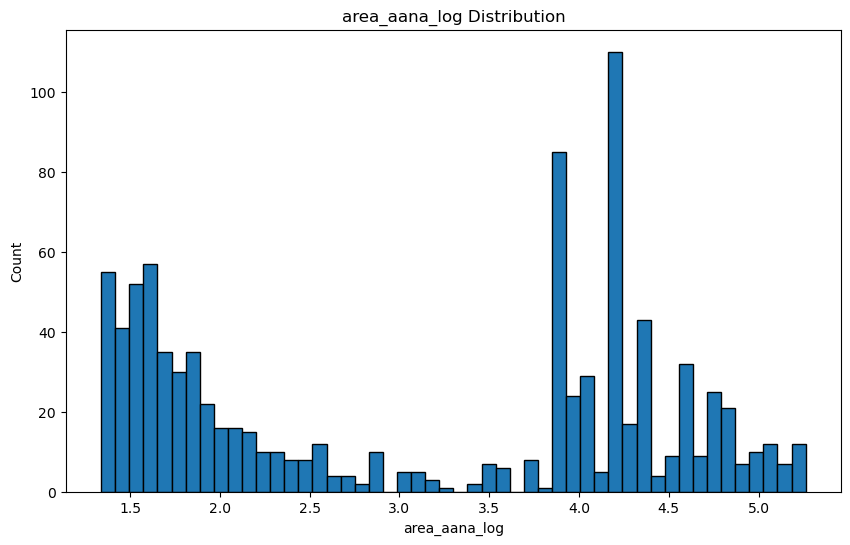

       Price  area_aana  price_per_aana
0   90000000      16.00    5.625000e+06
1   80000000      21.00    3.809524e+06
2   70000000      17.00    4.117647e+06
3  130000000      10.25    1.268293e+07
4  100000000      19.50    5.128205e+06
count    9.410000e+02
mean     4.180787e+06
std      2.554185e+07
min      3.472222e+00
25%      3.582317e+05
50%      6.250000e+05
75%      5.571429e+06
max      6.000000e+08
Name: price_per_aana, dtype: float64


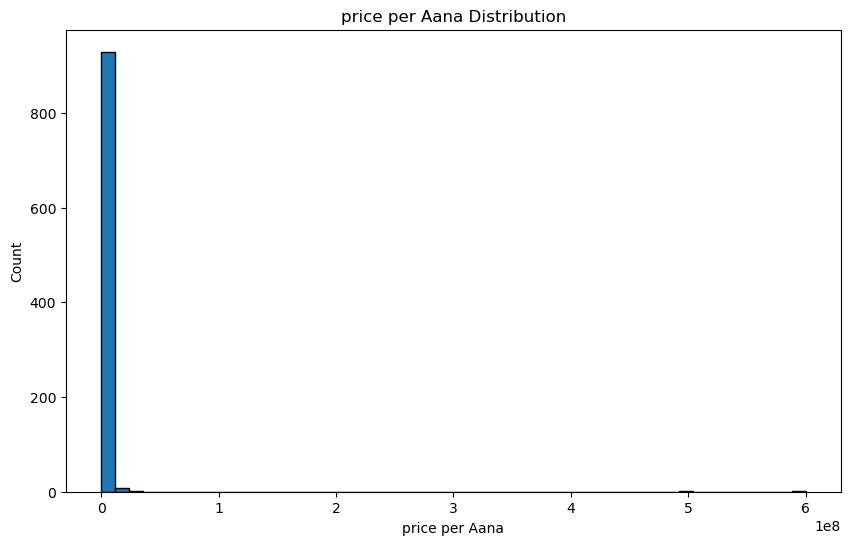

Rows after dropping floor and impossible ceiling: 920

Dropping Complete. Let's check the maximum and minimum values now:
Price_total       6.000000e+08
price_per_aana    3.368421e+07
dtype: float64
Price_total       450000.0
price_per_aana    100000.0
dtype: float64


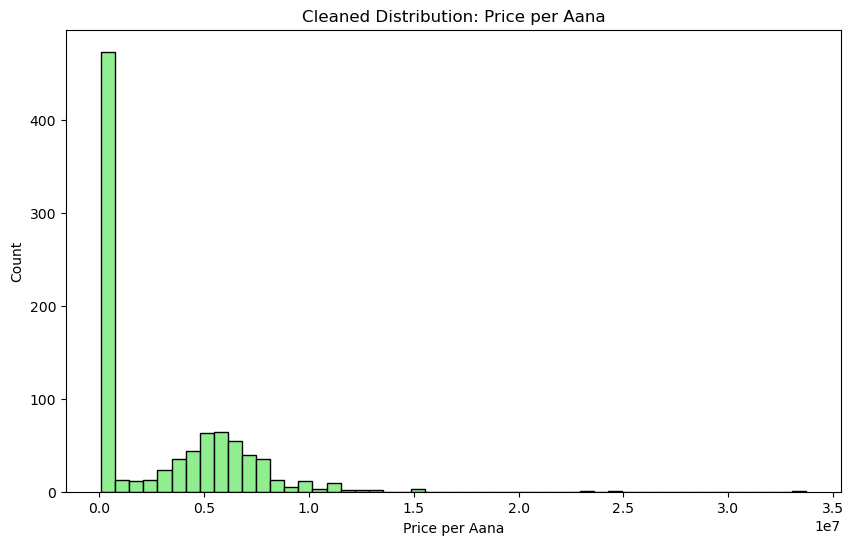

Original Area Skewness: 1.84
Log Transformed Area Skewness: 0.12


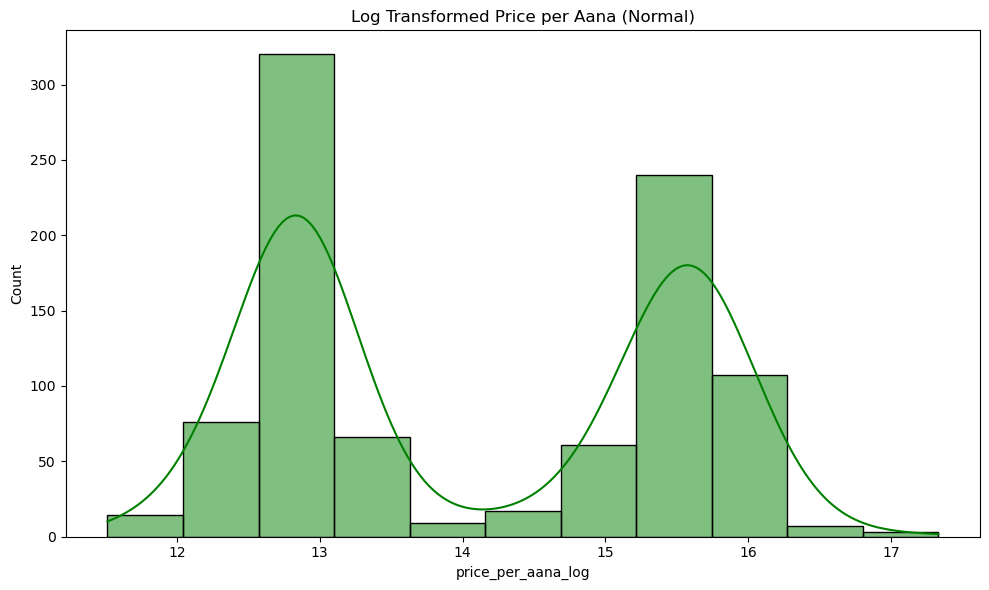

Build Area Stats:
count          920
unique         143
top       N/A Aana
freq           346
Name: Build Area, dtype: object

Null values: 0
Build Area colulmn is not considered as feature because of 40% of data is N/A aana and Build Area is greater than Area in many rows too which is impossible and hence dropped
We have more reliable feature columns - Area and Price_per_aana:
Columns successfully dropped!
Current columns: ['Address', 'City', 'Price', 'Bedroom', 'Bathroom', 'Floors', 'Parking', 'Face', 'Year', 'Area', 'Road Width', 'Road Type', 'Build Area', 'Amenities', 'Area_fixed', 'value_raw', 'unit_raw', 'unit_clean', 'unit_final', 'land_system', 'unit_invalid_flag', 'value_norm', 'is_bad', 'valid_format_flag', 'area_aana', 'title_clean', 'area_aana_log', 'price_per_aana', 'Price_total', 'price_per_aana_log']
Remaining shape: (920, 30)
count    920.000000
mean      14.710870
std        7.366593
min        0.000000
25%       13.000000
50%       14.000000
75%       18.000000
max   

In [1]:
from config import *
print("✓ Config imported successfully!")
import pandas as pd
import os
print(os.getcwd())
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from collections import Counter
import re
from ydata_profiling import ProfileReport
df=pd.read_csv("Housingdataset2020.csv")
print(f" Total Rows : {df.shape[0]}")
###profile = ProfileReport(df[['Area']], explorative=True)
###profile.to_file("area_report.html")
# Area preprocessing-------------------
print(df['Area'].sample(5))
print(df['Area'].value_counts().head(5))
print(df['Area'].isna().sum())
print(f"Duplicate rows found: {df.duplicated().sum()}")
# If it's more than 0, can be dropped :
# df_house2 = df_house2.drop_duplicates()

# ── PRE-FILTER: DROP GARBAGE ROWS BEFORE CONVERSION ─────────
# These cannot be safely cleaned by the conversion function
# because the garbage is in the unit/context, not the number
# Using DROP_AREA_VALUES from config.py
# (Remove the entire list definition)
df = df[~df['Area'].isin(drop_area_values)]
print(f"After dropping garbage: {df.shape[0]} rows remaining")
###Area classification ----------------
def fix_number_format(text):
    if pd.isna(text):
        return text
    
    text = str(text)
    
    # fix "3 .5" → "3.5"
    text = re.sub(r'(\d)\s*\.\s*(\d)', r'\1.\2', text)
    
    return text
df['Area_fixed'] = df['Area'].apply(fix_number_format)    
def split_value_unit(text):
    if pd.isna(text):
        return None, None
    
    text = str(text).strip().lower()

    # number + rest
    match = re.match(r'^([\d\.\-\*\/x]+)\s*(.*)$', text)

    if match:
        value = match.group(1)
        unit = match.group(2)
        return value, unit
    
    return None, None
df[['value_raw', 'unit_raw']] = df['Area_fixed'].apply(
    lambda x: pd.Series(split_value_unit(x))
)    
def clean_unit(unit):
    if pd.isna(unit):
        return None
    
    unit = str(unit).lower()
    
    # remove dots and spaces
    unit = unit.replace('.', '')
    unit = re.sub(r'\s+', '', unit)
    
    return unit
df['unit_clean'] = df['unit_raw'].apply(clean_unit)    
def normalize_unit(u):
    if pd.isna(u):
        return None

    u = str(u).lower()

    # remove dots and spaces
    u = u.replace('.', '')
    u = re.sub(r'\s+', '', u)

    # STANDARD SYSTEM (SQFT)
    if re.search(r'sqft|sqfeet|squarefeet|squareft|ft2', u):
        return 'sqft'

    # STANDARD SYSTEM (SQM)
    if re.search(r'sqm|sqmeter|squaremeter|m2|m²', u):
        return 'sqm'

    # HILL SYSTEM
    if 'ropani' in u:
        return 'ropani'
    if 'aana' in u:
        return 'aana'
    if 'paisa' in u:
        return 'paisa'
    if 'dam' in u:
        return 'dam'

    # TERAI SYSTEM
    if 'bigha' in u:
        return 'bigha'
    if 'kattha' in u:
        return 'kattha'
    if 'dhur' in u:
        return 'dhur'

    # LOCAL SYSTEM
    if 'haat' in u:
        return 'haat'

    return 'unknown'
    
    
df['unit_final'] = df['unit_clean'].apply(normalize_unit)    
def classify_system(unit):
    if pd.isna(unit):
        return 'missing'
    
    if unit in ['aana', 'ropani', 'paisa', 'dam']:
        return 'hill_system'
    
    if unit in ['bigha', 'kattha', 'dhur']:
        return 'terai_system'
    
    if unit == 'haat':
        return 'local_system'
    
    if unit in ['sqft', 'sqm']:
        return 'standard_system'
    
    return 'unknown'
df['land_system'] = df['unit_final'].apply(classify_system)    
print(df['land_system'].value_counts())
print(df[df['land_system'] == 'missing'][['Area', 'value_raw', 'unit_raw', 'unit_clean', 'unit_final']])
print(df['unit_final'].value_counts())
print(df[df['Area'].str.contains('5bigha', na=False)][
    ['Area','value_raw','unit_raw','unit_clean','unit_final']
])
print(df[df['unit_final'].str.contains('bigha', na=False)][
    ['Area','value_raw','unit_raw','unit_clean','unit_final']
].head(20))
###print(df[df['value_raw'].isna()][['Area','value_raw','unit_raw']].head(20))
###print(df[df['Area'].str.contains(r'[\*/]', na=False)])
###Each Area value conversion to same case-----------
###profile = ProfileReport(df[['value_raw', 'unit_final', 'land_system']], explorative=True)
###profile.to_file("area_report 1.html")
"""def has_letters(v):
    if pd.isna(v):
        return False
    return bool(re.search(r'[a-zA-Z]', str(v)))
df['has_letters_in_value'] = df['value_raw'].apply(has_letters)
value_issues = df[df['has_letters_in_value'] == True]
print(value_issues[['value_raw', 'unit_final', 'land_system']].head(20))
def has_invalid_chars(u):
    if pd.isna(u):
        return False
    
    u = str(u)
    
    # check digits or * or /
    return bool(re.search(r'[0-9*/]', u))
df['has_issue'] = df['unit_final'].apply(has_invalid_chars)
problem_rows = df[df['has_issue'] == True]
print(problem_rows[['unit_final', 'land_system']].head(20))"""

def is_invalid_unit(u):
    if pd.isna(u):
        return True
    
    u = str(u).lower().strip()
    
    # valid only if EXACT match
    if u in allowed_units:
        return False
    
    return True
df['unit_invalid_flag'] = df['unit_final'].apply(is_invalid_unit)
invalid_units_df = df[df['unit_invalid_flag'] == True]
print(invalid_units_df[['unit_final', 'land_system']].head(30))
###Dropping the invalid/missing row- 
df = df[~((df['unit_final'].isna()) & (df['land_system'] == 'missing'))]
print(df[df['land_system'] == 'missing'])
###Conversion of value_raw-
mixed_dash_slash = df[
    df['value_raw'].astype(str).str.contains('-', na=False) &
    df['value_raw'].astype(str).str.contains('/', na=False)
]

print("Rows with '-' AND '/' :", mixed_dash_slash.shape[0])
print(mixed_dash_slash[['Area', 'value_raw']].head(20))
slash_only = df[
    df['value_raw'].astype(str).str.contains('/', na=False)
]

print("Rows with '/' :", slash_only.shape[0])
print(slash_only[['Area', 'value_raw']].head(20))
def normalize_value(v):
    if pd.isna(v):
        return None
    v = str(v).lower().strip()
    v = v.replace('x', '*')
    v = re.sub(r'\s+', '', v)
    return v
def is_mixed_or_invalid(value, unit):
    if value is None:
        return True

    value = str(value)
    unit = str(unit).lower() if unit is not None else ""

    # ❌ Case 1: mixed '-' and '/'
    if '-' in value and '/' in value:
        return True

    # ❌ Case 2: haat unit with '/'
    if unit == 'haat' and '/' in value:
        return True

    # ❌ Case 3: multiple '/'
    if value.count('/') > 1:
        return True

    return False


def is_valid_number(n):
    
    """Check if string can be converted to float."""
    if not n:
        return False
    try:
        float(n)
        return True
    except:
        return False

def is_valid_value_simple(v):

    if v is None:
        return False


    # ✔ allow only safe characters
    if not re.match(r'^[0-9.\-*/]+$', v):
        return False

    parts = v.split('-')

    for part in parts:

        # Case A: pure number
        if is_valid_number(part):
            continue

        # Case B: multiplication
        elif '*' in part:
            nums = part.split('*')
            if len(nums) != 2:
                return False
            if not all(is_valid_number(n) for n in nums):
                return False

        # Case C: division (ONLY pure fraction allowed here)
        elif '/' in part:
            if part.count('/') != 1:
                return False
            nums = part.split('/')
            if len(nums) != 2:
                return False
            if not all(is_valid_number(n) for n in nums):
                return False

        else:
            return False

    return True
df['value_norm'] = df['value_raw'].apply(normalize_value)
df['is_bad'] = df.apply(
    lambda row: is_mixed_or_invalid(row['value_raw'], row['unit_final']), ### Non-validation
    axis=1
)
print(df['is_bad'].value_counts(dropna=False)) ### True in output = Values dropped and False in output = Values kept 
print(df[df['is_bad'] == True][['Area', 'value_raw', 'unit_final']])
df = df[~df['is_bad']].copy()

df['valid_format_flag'] = df['value_norm'].apply(is_valid_value_simple)### Validation

removed = df[~df['valid_format_flag']]
print(removed[['Area', 'value_raw', 'unit_final']].head(20))
print("Total removed by validation:", removed.shape[0])

df1 = df[df['valid_format_flag'] == True].copy()
print(" Total Valid rows:", df1.shape[0]) 
slash_rows = df1[df1['value_raw'].astype(str).str.contains('/', na=False)] ### Quick check on valid slash values
print(slash_rows[['Area', 'value_raw', 'unit_final']])
haat_rows = df1[df1['unit_final'] == 'haat'] ###Quick check on valid haat unit values
print(haat_rows[['Area', 'value_raw', 'unit_final']])

###Conversion to aana------------------------------------------------------------------------------

# All conversion constants imported from config.py
def safe_float(x):
    try:
        return float(x)
    except:
        return np.nan

def eval_simple_expr(expr):
    """
    Handles:
    - 2*3
    - 6/3
    - 1/2.5
    """
    if '*' in expr:
        a, b = expr.split('*')
        return safe_float(a) * safe_float(b)

    if '/' in expr:
        a, b = expr.split('/')
        if safe_float(b) == 0:
            return np.nan
        return safe_float(a) / safe_float(b)

    return safe_float(expr)    
def parse_hierarchy(value, unit):
    if value is None:
        return np.nan

    parts = value.split('-')
    parts = [eval_simple_expr(p) for p in parts if p != '']
    parts = [p for p in parts if not np.isnan(p)]

    # ---------------- HILL SYSTEM ----------------
    if unit in ['aana', 'ropani']:
        while len(parts) < 4:
            parts.append(0)
        parts = parts[:4]

        r, a, p, d = parts
        return (
            r * ROPANI_TO_AANA +
            a +
            p * PAISA_TO_AANA +
            d * DAM_TO_AANA
        )

    # ---------------- TERAI SYSTEM ----------------
    if unit == 'bigha':
        while len(parts) < 3:
            parts.append(0)
        parts = parts[:3]

        b, k, d = parts
        return (
            b * BIGHA_TO_AANA +
            k * KATTHA_TO_AANA +
            d * DHUR_TO_AANA
        )

    if unit == 'kattha':
        while len(parts) < 2:
            parts.append(0)
        parts = parts[:2]

        k, d = parts
        return k * KATTHA_TO_AANA + d * DHUR_TO_AANA

    if unit == 'dhur':
        return parts[0] * DHUR_TO_AANA if parts else np.nan

    # ---------------- SMALL UNITS ----------------
    if unit == 'paisa':
        while len(parts) < 2:
            parts.append(0)
        parts = parts[:2]

        p, d = parts
        return p * PAISA_TO_AANA + d * DAM_TO_AANA

    if unit == 'dam' or unit == 'daam':
        return parts[0] * DAM_TO_AANA if parts else np.nan

    return np.nan
def convert_to_aana(value, unit):
    if value is None or unit is None:
        return np.nan

    unit = str(unit).lower()
    value = normalize_value(value)

   
    # ---------------- SQFT ----------------
    if unit == 'sqft':
        if '*' in value:
            return eval_simple_expr(value) * SQFT_TO_AANA
        if '/' in value:
            parts = value.split('/')
            if len(parts) == 2:
                return eval_simple_expr(value) * SQFT_TO_AANA
            return np.nan 
        return safe_float(value) * SQFT_TO_AANA

    

    # ---------------- SQM ----------------
    if unit == 'sqm':
        if '*' in value:
            return eval_simple_expr(value) * SQMT_TO_AANA
        if '/' in value:
            parts = value.split('/')
            if len(parts) == 2:
                return eval_simple_expr(value) * SQMT_TO_AANA
            return np.nan 
        return safe_float(value) * SQMT_TO_AANA
 
        
      
    # ---------- HAAT ----------
    if unit == 'haat':
        if '/' in value:
            return np.nan   # dropped as per your rule
        if '*' in value:
            return eval_simple_expr(value) * HAAT_TO_AANA
        return safe_float(value) * HAAT_TO_AANA

   
    return parse_hierarchy(value, unit)
df1['value_norm'] = df1['value_raw'].apply(normalize_value)

df1['area_aana'] = df1.apply(
    lambda row: convert_to_aana(row['value_raw'], row['unit_final']),
    axis=1
)    
print(df1[['value_raw', 'unit_final', 'area_aana']].head(20))

print("\nMissing conversions:", df1['area_aana'].isna().sum())

missing_rows = df1[df1['area_aana'].isna()]
print("Total missing:", missing_rows.shape[0])
print(missing_rows[['Area', 'value_raw', 'unit_final', 'value_norm']].head(20))

print("\nFinal stats:")
print(df1['area_aana'].describe())### Remainder : df1['area_aana'] is actually a column

df2 = df1[~df1['area_aana'].isna()].copy()

# remove very small plots (not suitable for house construction)

df2 = df2[df2['area_aana'] >= MIN_AREA_AANA].copy()
print("After removing < 2.8 aana:", df2.shape[0])
print("Before:", df1.shape[0])
print("After :", df2.shape[0])
print("Dropped:", df1.shape[0] - df2.shape[0])
print(f"Final valid rows: {df2.shape[0]}")
print(f"Area_aana stats:")
print(df2['area_aana'].describe()) ### Here, df1 and df2 describe() might give same results because describe() 
                                   ### ignores missing or NAN values.

### Filtering title column -

df2['title_clean'] = (
    df2['Title']
    .astype(str)
    .str.lower()
    .str.replace(r'[^a-z0-9 ]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
land_sale_mask = df2['title_clean'].str.contains(
    r'\bland\b.*\bsale\b|\bsale\b.*\bland\b',
    na=False
)
land_for_sale_rows = df2[land_sale_mask]
print("Number of 'land for sale' rows:", land_for_sale_rows.shape[0])
### In dataset , we have 665 rows which contains "land for sale" which means they are land prices,
### So, I will work on 2 projects house price prediction and land price prediction from this given data only.
### Let me separate 2 price dataframes, one for house price predictin and another for land price prediction
df_land = land_for_sale_rows.copy()
df_house = df2[~land_sale_mask].copy()
### Check :
print("Total rows:", df2.shape[0])
print("House rows:", df_house.shape[0])
print("Land rows :", df_land.shape[0])
print("Check sum :", df_house.shape[0] + df_land.shape[0])
# Check for other land-related titles in house dataframe
land_keywords = r'plot.*sale|agricultural.*land.*sale|residential.*land.*sale|जग्गा.*sale|plot.*sell'
for keyword in land_keywords.split('|'):
    count = df_house['Title'].astype(str).str.lower().str.contains(
        keyword, regex=True, na=False
    ).sum()
    
    print(f"'{keyword}' in house titles: {count} rows")

### Let me work for house price prediction first----------------------------------------------------------
### Check for house for sale and rent rows (for all land ,office, house e.t.c) in df_house data frame :---------------------------------------------------------------
# Combine all "trash" keywords into one search string
rent_keywords = r'\brent\b|for\s*rent|house.*rent|flat.*rent|office.*rent|lease|rental'

rent_mask = df_house['Title'].astype(str).str.lower().str.contains(
    rent_keywords,
    regex=True,
    na=False
)

rent_rows = df_house[rent_mask]

print("Number of rent listings:", rent_rows.shape[0])
print(rent_rows[['Title', 'Price', 'area_aana']].head(20))
df_house1 = df_house[~rent_mask].copy()

print("Before:", df_house.shape[0])
print("After :", df_house1.shape[0])
print("Removed:", df_house.shape[0] - df_house1.shape[0])

###Removing outliers of area_aana-----------------------------------------

print("area_aana stats in df_house1")
print(df_house1['area_aana'].describe())
print(df_house1[['area_aana']].describe(percentiles=[.95, .99]))
df_house1 = df_house1[df_house1['area_aana'] <= 192].copy()
print("After removing extreme outliers in area_aana")
print(df_house1['area_aana'].describe())

###log transform to area_aana and histogram visualization of log transformed data-----------------------------------

df_house1['area_aana_log'] = np.log1p(df_house1['area_aana'])
print(f"Original Area Skewness: {df_house1['area_aana'].skew():.2f}")
print(f"Log Transformed Area Skewness: {df_house1['area_aana_log'].skew():.2f}")
plt.figure(figsize=(10,6))

plt.hist(df_house1['area_aana_log'], bins=50, edgecolor='black')
plt.title('area_aana_log Distribution')
plt.xlabel('area_aana_log')
plt.ylabel('Count')

plt.show()


### Now, Work on price per aana-----------------------------

df_house1['price_per_aana'] = df_house1['Price'] / df_house1['area_aana']
# show results
print(df_house1[['Price', 'area_aana', 'price_per_aana']].head(5))
print(df_house1['price_per_aana'].describe())

### Histogram Visualization -------------------------------------------------------------------------------
plt.figure(figsize=(10,6))

plt.hist(df_house1['price_per_aana'], bins=50, edgecolor='black')
plt.title('price per Aana Distribution')
plt.xlabel('price per Aana')
plt.ylabel('Count')

plt.show()
###Check values and their distribution to decide capping----------------------------------------------
"""
print(df_house1[df_house1['price_per_aana'] < 1000000][
    ['Price', 'area_aana', 'price_per_aana', 'Title']
].shape[0])
print(
    df_house1[['City','Price', 'area_aana', 'price_per_aana']]
    .sort_values('price_per_aana', ascending=False)
    .head(40)
)
print(
    df_house1[['City','Price', 'area_aana', 'price_per_aana']]
    .sort_values('price_per_aana')
    .head(40)
)"""
###Dropping garbage values --------------------------------------------------------------------------------------------------
# --------------------------------------------------------- 
# Based on my observation, 60Cr and 50Cr are impossible.
# Let's drop anything above 3 Crore 50 lakhs (35,000,000) as errors.
df_house2 = df_house1[(df_house1['price_per_aana'] >= MIN_PRICE_PER_AANA) & 
                      (df_house1['price_per_aana'] < MAX_PRICE_PER_AANA)].copy()

print(f"Rows after dropping floor and impossible ceiling: {df_house2.shape[0]}")

# ---------------------------------------------------------

# RECALCULATE TOTAL PRICE
df_house2['Price_total'] = df_house2['price_per_aana'] * df_house2['area_aana']
print("\nDropping Complete. Let's check the maximum and minimum values now:")
print(df_house2[['Price_total', 'price_per_aana']].max())
print(df_house2[['Price_total', 'price_per_aana']].min())

# Visualize the cleaned, dropped data

plt.figure(figsize=(10,6))
plt.hist(df_house2['price_per_aana'], bins=50, edgecolor='black', color='lightgreen')
plt.title('Cleaned Distribution: Price per Aana')
plt.xlabel('Price per Aana')
plt.ylabel('Count')
plt.show()

# Histogram AFTER Log Transform

# 1. Apply Log Transformation
# We create a new column so we don't lose the original data
df_house2['price_per_aana_log'] = np.log1p(df_house2['price_per_aana'])
print(f"Original Area Skewness: {df_house2['price_per_aana'].skew():.2f}")
print(f"Log Transformed Area Skewness: {df_house2['price_per_aana_log'].skew():.2f}")
plt.figure(figsize=(10,6))
sns.histplot(df_house2['price_per_aana_log'], kde=True, color='green')
plt.title('Log Transformed Price per Aana (Normal)')
plt.tight_layout()
plt.show()

###Check on build Area-------------------------------------------------------------------------------------------------
print("Build Area Stats:")
print(df_house2['Build Area'].describe())
print(f"\nNull values: {df_house2['Build Area'].isna().sum()}")
print("Build Area colulmn is not considered as feature because of 40% of data is N/A aana and Build Area is greater than Area in many rows too which is impossible and hence dropped")
print("We have more reliable feature columns - Area and Price_per_aana:")

###Check for other unwanted columns----------------------------------------------------------------------------------

### Columns like Views and Posted are dropped because they have no effect on target (Price or Price_per_aana)-----------------------
### And Road column is also dropped as it's data is already extracted in Road Width and Road Type columns---------------------
### Now, We can  Title column is also dropped as it has no effect on target----------------------------------------
### Dropping of unwanted columns------------------------------------------------

cols_to_drop = [ 'Posted', 'Views', 'Road', 'Title']
# Dropping them from df_house2-----------------------------------
# axis=1 specifies we are dropping columns, not rows-------------
df_house2 = df_house2.drop(columns=cols_to_drop, errors='ignore')
# Verify the result
print("Columns successfully dropped!")
print(f"Current columns: {df_house2.columns.tolist()}")
print(f"Remaining shape: {df_house2.shape}")

### Other dropping of columns will be done at final phase before applying ML model-----------------------------------

# Road width preprocessing-------------------------------------------------------------------------------------------

df_house2['RoadWidth_feet'] = pd.to_numeric(
    df_house2['Road Width'].str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce')
print(df_house2['RoadWidth_feet'].describe())
# ── STEP 1: CHECK UNITS PRESENT ──────────────────────────────
feet_count = df_house2['Road Width'].str.contains(
                'Feet', case=False, na=False).sum()
meter_count = df_house2['Road Width'].str.contains(
                'Meter', case=False, na=False).sum()

print(f"Feet rows: {feet_count}")
print(f"Meter rows: {meter_count}")
# METER_TO_FEET imported from config.py
def roadwidth_to_feet(val):
    val = str(val).strip()
    
    # Extract the number from the string
    match = re.search(r'(\d+\.?\d*)', val)
    if not match:
        return np.nan
    
    num = float(match.group(1))
    
    # Convert based on unit
    if 'Meter' in val or 'meter' in val:
        return num * METER_TO_FEET  # convert meter to feet
    elif 'Feet' in val or 'feet' in val:
        return num                   # already in feet
    else:
        return np.nan               # unknown unit

df_house2['RoadWidth_feet'] = df_house2['Road Width'].apply(roadwidth_to_feet)

print(f"\nAfter unit conversion:")
print(df_house2['RoadWidth_feet'].describe())
# ── STEP 3: DROP ROWS OUTSIDE NEPAL ROAD STANDARD ────────────
# Nepal Road Standard 2076 — minimum 10 feet, maximum 48 feet (Approximateed values)
# for residential/local roads

before = df_house2.shape[0]

df_house2 = df_house2[
    (df_house2['RoadWidth_feet'] >= MIN_ROAD_WIDTH_FEET) &   # minimum 10 feet
    (df_house2['RoadWidth_feet'] <= MAX_ROAD_WIDTH_FEET)      # maximum 48 feet
]

after = df_house2.shape[0]

print(f"\nRows before filter: {before}")
print(f"Rows after filter:  {after}")
print(f"Rows dropped:       {before - after}")
print(f"\nFinal Road Width statistics:")
print(df_house2['RoadWidth_feet'].describe())

### Check for bedroom,bathroom,floors,parking and year columns for data cleaning

numeric_cols = ['Bedroom', 'Bathroom', 'Floors', 
                'Parking', 'Year']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  dtype: {df_house2[col].dtype}")
    print(f"  nulls: {df_house2[col].isna().sum()}")
    print(f"  min: {df_house2[col].min()}")
    print(f"  max: {df_house2[col].max()}")
    print(f"  unique values: {sorted(df_house2[col].unique())}")

### Year column has 493 null values which is greater than 50% of number of valid rows---------------------
###So,dropping Year column would be better instead of handling or imputing the missing values-------------------------

df_house2 = df_house2.drop(columns= 'Year' , errors='ignore')
###To check remaining columns run the line of code given below----------------------------
"""print(f"Current columns: {df_house2.columns.tolist()}")"""
### Checking --------------------------------------------------------------------------------
print(df_house2[['Bedroom', 'Bathroom', 'Floors', 'Parking']].describe(percentiles=[.95, .99]))

###Floor column also has 215 null values, but it cannot be dropped---------------------------------------------
### It is because , floor can be one of the important feature for target----------------------------------------
### So, let's use simple imputer from Scikit learn documentation-------------------------------------------------------------------------------

# 1. Initialize the Imputer with 'median' strategy---------------------------
imputer = SimpleImputer(strategy='median')

# 2. Fit and transform the Floors column----------------------------
# Scikit-learn expects a 2D array, so we use [[ ]]------------------------
df_house2['Floors'] = imputer.fit_transform(df_house2[['Floors']])

print(f"Nulls in Floors after imputer: {df_house2['Floors'].isna().sum()}")
print(f"New Median Floor Value: {df_house2['Floors'].median()}")

### Handling outliers or impossible values in bedroom, bathroom, parking and floor columns----------------------------

print(df_house2[['Bedroom', 'Bathroom', 'Floors', 'Parking']].describe(percentiles=[.95, .99]))

# 1. Define our "Sanity Limits" based on 99% stats
# We use a dictionary NUMERIC_LIMITS to keep the code organized
# 2. Clean the Minimums (Replace 0 with Median)
# We do this first because a house must have at least 1 floor or room
cols_to_fix_min = ['Bedroom', 'Bathroom', 'Floors']
for col in cols_to_fix_min:
    median_val = df_house2[col].median()
    df_house2[col] = df_house2[col].replace(0, median_val)

# 3. Clean the Maximums (Clip at the 99th percentile)
for col, limit in NUMERIC_LIMITS.items():
    df_house2[col] = df_house2[col].clip(upper=limit)

# 4. Final Verification
print("Cleaning Complete!")
print(df_house2[['Bedroom', 'Bathroom', 'Floors', 'Parking']].describe())

### Now, Encoding for categorical text columns----------------------------------------------------------------------------------

cols = ['City', 'Face', 'Road Type','Address','Amenities']

print("Null values in each column:\n")
print(df_house2[cols].isna().sum())

### Only Road Type column has null values:----------------------------------------------------------------------
### For Road Type column,  processing null values:----------------------------------------------------------------------------------------------

# Step 1: Create missing indicator 
df_house2['RoadType_missing'] = df_house2['Road Type'].isna().astype(int)

# Step 2: Fill missing
df_house2['Road Type'] = df_house2['Road Type'].fillna('unknown')


### Checking for unique values in categorical columns except Amenities and Address :---------------------------------------------------------------------------------------

cols = ['City', 'Face', 'Road Type']

for col in cols:
    
    print("Unique values:")
    print(df_house2[col].unique())

### Normalize City ,Face and Road Type column:-----------------------------------------------------------------------------

def clean_text(col):
    return (
        col.astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r'[^a-z0-9\s]', '', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

df_house2['City'] = clean_text(df_house2['City'])
df_house2['Face'] = clean_text(df_house2['Face'])
df_house2['Road Type'] = clean_text(df_house2['Road Type'])

###Cleaning function for Address column-----------------------------------------------------------

def clean_address(col):
    return (
        col.astype(str)
        .str.lower()                         # lowercase
        .str.strip()                         # remove leading/trailing spaces
        .str.replace(r'\s*,\s*', ', ', regex=True)  # fix spaces around commas
        .str.replace(r'\s+', ' ', regex=True)       # collapse multiple spaces
        .str.strip()                         # final cleanup
    )
df_house2['Address'] = clean_address(df_house2['Address'])

print(df_house2['Address'].sample(20, random_state=42))
print(df_house2['Address'].str.split(',').head(10))

### Address column have 3, 6 ,4 comma separated values in different rows--------------------------------------------- 
###let's split the values and then remove duplicate values---------------------------------------------------------

def process_address(text):
    # convert to string + basic safety
    text = str(text).lower().strip()

    # split by comma
    parts = text.split(',')

    # clean each part
    parts = [p.strip() for p in parts if p.strip() != '']

    # remove duplicates while preserving order
    seen = set()
    unique_parts = []

    for p in parts:
        if p not in seen:
            unique_parts.append(p)
            seen.add(p)

    return unique_parts

df_house2['Address'] = df_house2['Address'].apply(process_address)
print(df_house2['Address'].sample(20, random_state=42))

### Comparing the City column and Adress column to drop the additional information of city in Address column-----------------------------

def remove_city_from_address(row):
    city = str(row['City']).strip().lower()
    address_parts = row['Address']

    # remove city if present
    cleaned_parts = [p for p in address_parts if p != city]

    return cleaned_parts

df_house2['Address'] = df_house2.apply(remove_city_from_address, axis=1)
print(df_house2['Address'].sample(20, random_state=42))

### Using the Global Frequency Master Dictionary to find the most frequent neighbourhood-----------------------------

# Step 1: Count how often EVERY single token appears across the entire dataset
all_tokens = []
for token_list in df_house2['Address']:
    all_tokens.extend(token_list)

global_counts = Counter(all_tokens)

# banned_tokens imported from config.py

# Step 3: Create a function to find the most common token in a row's list
def extract_best_neighborhood(token_list):
    
    # Filter out any junk words like 'na' from this row's list first
    valid_tokens = [t for t in token_list if t not in banned_tokens]
    
    # If there are no valid tokens left at all, default to 'unknown'
    if not valid_tokens:
        return 'unknown'
    
    # Look at the tokens in this specific row and find their global popularity
    # Example: for ['pasikot', 'budhanilkantha'], pasikot=12, budhanilkantha=147
    # It will pick 'budhanilkantha' because 147 > 12
    best_token = max(valid_tokens, key=lambda token: global_counts[token])
    
    return best_token

# Step 4: Extract the neighborhood and calculate its final frequency
df_house2['Neighborhood'] = df_house2['Address'].apply(extract_best_neighborhood)
final_neighborhood_counts = df_house2['Neighborhood'].value_counts()

# Step 5: Print the results
print("=" * 60)
print(f"TOTAL UNIQUE NEIGHBORHOODS EXTRACTED: {df_house2['Neighborhood'].nunique()}")
print("=" * 60)
print("\nMOST FREQUENT NEIGHBORHOODS (HEAD):")
print("-" * 60)
print(final_neighborhood_counts.head(20))

print("\n" + "-" * 60)
print("LEAST FREQUENT NEIGHBORHOODS (TAIL) - Potential Outliers/Lanes:")
print("-" * 60)
print(final_neighborhood_counts.tail(20))
print("=" * 60)

### Now, Suitable encoding here can be target encoding with smoothing to reduce data leakage risk-------------------
### Or, One hot encoding if we can compress the locations with frequency 1 into "Other" bucket----------------------
### I decided to do one hot encoding------------------------------------------------

# 1.Identify the top 20 most frequent neighborhoods
top_neighborhoods = df_house2['Neighborhood'].value_counts().head(TOP_NEIGHBORHOODS).index

# 2.Map anything outside the top 20 to the 'other' bucket
df_house2['Neighborhood_Grouped'] = df_house2['Neighborhood'].apply(
    lambda x: x if x in top_neighborhoods else 'other'
)

# 3.One-Hot Encode the 21 unique categories (top_neighborhoods (20) + 'other')

encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=int)

# 2.Fit and Transform the grouped neighborhood column
# We use [['column']] because Scikit-learn expects a 2D array (DataFrame format)
neighborhood_encoded = encoder.fit_transform(df_house2[['Neighborhood_Grouped']])

# 3.Grab the clean feature names generated by Scikit-learn
encoded_column_names = encoder.get_feature_names_out(['Neighborhood_Grouped'])

# 4.Convert the result into a clean DataFrame with the proper column names
df_encoded_columns = pd.DataFrame(
    neighborhood_encoded, 
    columns=encoded_column_names, 
    index=df_house2.index
)

# 5.Concatenate back to the main DataFrame and drop the old text columns
df_house2 = pd.concat([df_house2, df_encoded_columns], axis=1)
df_house2 = df_house2.drop(columns=['Address', 'Neighborhood', 'Neighborhood_Grouped'])

# Verify the new shape and see your final column layout!
print(f"Dataframe shape after Sklearn encoding: {df_house2.shape}")
print("\nSample of the new engineered columns:")
print(encoded_column_names[:5])


### One hot encoding for Road Type, City, Face----------------------------------------------------------------------- 

###For quick EDA, we can use this pandas dummy method----------------------------------
"""df_house2 = pd.get_dummies(df_house2, columns=['City', 'Face',], drop_first=True)""" 

###For ML model pipleline-------------------------------------------------------------------------------------------
encoder = OneHotEncoder( drop='first' , handle_unknown='ignore', sparse_output=False)

encoded = encoder.fit_transform(df_house2[['City', 'Face','Road Type']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['City', 'Face','Road Type']),
    index=df_house2.index
)

df_house2 = pd.concat([df_house2, encoded_df], axis=1)
df_house2.drop(columns=['City', 'Face','Road Type'], inplace=True)

encoded_cols = encoder.get_feature_names_out(['City', 'Face', 'Road Type'])
print(encoded_cols)

### Encoding for Amenities column-----------------------------------------------------------------------------

# Step 1: Safely convert text strings into actual Python lists
def clean_to_list(cell):
    if isinstance(cell, str) and cell.strip():
        try:
            return ast.literal_eval(cell)
        except (ValueError, SyntaxError):
            return [] # Return an empty list if the formatting is broken
    return []

# Apply the conversion to the whole column
df_house2['Amenities_Cleaned'] = df_house2['Amenities'].apply(clean_to_list)

# Step 2: Initialize and Fit the MultiLabelBinarizer
# It will scan all 868 rows and dynamically find EVERY unique amenity for you!
mlb = MultiLabelBinarizer()
amenities_encoded = mlb.fit_transform(df_house2['Amenities_Cleaned'])

# Step 3: Get the clean column names generated automatically by Sklearn
# We will add an 'amenity_' prefix so they are easy to identify later
encoded_column_names = [f"amenity_{name.strip().replace(' ', '_')}" for name in mlb.classes_]

# Step 4: Convert the result into a clean DataFrame
df_amenities_columns = pd.DataFrame(
    amenities_encoded, 
    columns=encoded_column_names, 
    index=df_house2.index
)

# Step 5: Combine back to your main dataframe and drop the old intermediate columns
df_house2 = pd.concat([df_house2, df_amenities_columns], axis=1)
df_house2 = df_house2.drop(columns=['Amenities', 'Amenities_Cleaned'])

print("=" * 60)
print(f"Total unique amenities dynamically discovered: {len(mlb.classes_)}")
print("=" * 60)
print("Discovered columns:")
print(encoded_column_names)

### One final check for which columns to drop to prevent data leakage----------------------------
df_house2.info()

### 11 object columns and 3 boolean columns found, let's take a look------------------------------

print("--- Features to Drop for Data Leakage / Formatting ---")
print("Text columns:", df_house2.select_dtypes(include=['object']).columns.tolist())
print("Boolean columns:", df_house2.select_dtypes(include=['bool']).columns.tolist())

### These 11 objects and 3 boolean columns are those intermediate columns created by us for different functions----------------------------------------
### We need to drop these columns along with few other columns to prevemt data leakage-------------------------------
### After that, We will split training(80%) and test data(20%)-------------------------------------------------
### Then , we will scale the features using one of the suitable techniques like normalization,standardization---------
### Then , we will apply ML model baselines------------------------------------------------------------

### Let's remove the unwanted/data leakage prone columns------------------------------------------------------

# List of prefixes or keywords to skip
encoded_keywords = ['amenity_', 'Neighborhood_Grouped_', 'City_', 'Face_', 'Road Type_']

# Filter out any column that starts with our encoded keywords
core_columns = [
    col for col in df_house2.columns 
    if not any(col.startswith(keyword) for keyword in encoded_keywords)
]

print(f"--- TRUE CORE COLUMNS ({len(core_columns)} total) ---")
for i, col in enumerate(core_columns, 1):
    print(f"{i}. {col}")

### Actual dropping ------------------------------------------------------------------------

# 1. Isolate the target variable (using our unskewed log column)
y = df_house2['price_per_aana_log']

# 2. Group all our specified drop columns into a single clean list

# Using columns_to_drop from config.py

# 3. Dropping them all at once to create your pure feature matrix X
X = df_house2.drop(columns=columns_to_drop)

# 4. Verifying the results
print("=" * 50)
print("            COLUMNS SUCCESSFULLY PURIFIED             ")
print("=" * 50)
print(f"Target vector (y) shape: {y.shape}")
print(f"Feature matrix (X) shape: {X.shape}")
print("-" * 50)
print(f"Total columns dropped: {len(columns_to_drop)}")
print(f"Remaining features in X: {X.shape[1]}")
print("=" * 50)

### Check the remaining columns----------------------------------------------------------------------------------

# List of prefixes or keywords to skip
encoded_keywords = ['amenity_', 'Neighborhood_Grouped_', 'City_', 'Face_', 'Road Type_']

# Filter X columns to show only the remaining unencoded features
remaining_core_features = [
    col for col in X.columns 
    if not any(col.startswith(keyword) for keyword in encoded_keywords)
]

print(f"--- REMAINING CORE FEATURES IN X ({len(remaining_core_features)} total) ---")
for i, col in enumerate(remaining_core_features, 1):
    print(f"{i}. {col}")

### Viewing/ checking the encoded columns-------------------------------------------------------------- 

# Keywords that identify our one-hot encoded columns
encoded_keywords = ['amenity_', 'Neighborhood_Grouped_', 'City_', 'Face_', 'Road Type_']

# Filter X to find columns that match those prefixes
encoded_columns = [
    col for col in X.columns 
    if any(col.startswith(keyword) for keyword in encoded_keywords)
]

print(f"--- ENCODED COLUMNS IN X ({len(encoded_columns)} total) ---")
for i, col in enumerate(sorted(encoded_columns), 1):
    print(f"{i}. {col}")

### Now let's split the training and test data--------------------------------------------------------------

# Execute the 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print("=" * 50)
print("             STEP 1: SPLITTING COMPLETE               ")
print("=" * 50)
print(f"Total Rows in Original Dataset: {len(X)}")
print("-" * 50)
print(f"Training Features (X_train) shape: {X_train.shape}  (80% of rows)")
print(f"Testing Features  (X_test) shape:  {X_test.shape}  (20% of rows)")
print("-" * 50)
print(f"Training Target   (y_train) shape: {y_train.shape}")
print(f"Testing Target    (y_test) shape:  {y_test.shape}")
print("=" * 50)


###Scaling of data --------------------------------------------------------------------------------------

# 1. Isolate the continuous columns that need scaling

# continuous_features imported from config.py

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Create deep copies of the datasets to avoid any Pandas Copy warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 4. FIT and TRANSFORM on Training data, only TRANSFORM on Testing data
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

print("=" * 60)
print("             STEP 2: FEATURE SCALING COMPLETE                 ")
print("=" * 60)
print("Sanity Check - Scaled Training Means (Should be extremely close to 0):")
print(f"  Bedroom mean:        {X_train_scaled['Bedroom'].mean():.4f}")
print(f"  area_aana_log mean:  {X_train_scaled['area_aana_log'].mean():.4f}")
print("-" * 60)
print("Sanity Check - Scaled Training Standard Deviations (Should be exactly 1):")
print(f"  RoadWidth_feet std:  {X_train_scaled['RoadWidth_feet'].std():.4f}")
print(f"  Floors std:          {X_train_scaled['Floors'].std():.4f}")
print("=" * 60)

### Let's view/compare the data-------------------------------------------------------------------------------------

# Create a temporary dataframe to look at a few rows side-by-side
comparison_df = pd.DataFrame({
    'Raw_RoadWidth': X_train['RoadWidth_feet'].head(5),
    'Scaled_RoadWidth': X_train_scaled['RoadWidth_feet'].head(5),
    'Raw_Floors': X_train['Floors'].head(5),
    'Scaled_Floors': X_train_scaled['Floors'].head(5)
})

print("=" * 65)
print("        SIDE-BY-SIDE: RAW VALUES VS. STANDARD SCALED VALUES     ")
print("=" * 65)
print(comparison_df)
print("=" * 65)

### Building baseline model (linear regression model)--------------------------------------------------------------

# 1. Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Predict and Reverse Log
y_pred_lr_log = lr_model.predict(X_test_scaled)
y_test_actual = np.expm1(y_test)
y_pred_lr_actual = np.expm1(y_pred_lr_log)

# 3. Evaluate
lr_mae = mean_absolute_error(y_test_actual, y_pred_lr_actual)
lr_r2 = r2_score(y_test_actual, y_pred_lr_actual)

print("=" * 50)
print("         BASELINE 1: LINEAR REGRESSION            ")
print("=" * 50)
print(f"R² Score (Variance Explained): {lr_r2*100:.1f}%")
print(f"Average Error (MAE):           Rs. {lr_mae:,.2f} per Aana")
print("=" * 50)

### let's check on other pipeline models (Random forest and XGBOOST)-------------------------------------------------

# =====================================================================
# BASELINE 2: RANDOM FOREST
# =====================================================================
rf_model = RandomForestRegressor(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
# We use the UNSCALED X_train, but KEEP the logged y_train
rf_model.fit(X_train, y_train)

y_pred_rf_log = rf_model.predict(X_test)
y_pred_rf_actual = np.expm1(y_pred_rf_log)

rf_r2 = r2_score(y_test_actual, y_pred_rf_actual)
rf_mae = mean_absolute_error(y_test_actual, y_pred_rf_actual)

# =====================================================================
# BASELINE 3: XGBOOST
# =====================================================================
xgb_model = XGBRegressor(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, learning_rate=LEARNING_RATE)
# We use the UNSCALED X_train, but KEEP the logged y_train
xgb_model.fit(X_train, y_train)

y_pred_xgb_log = xgb_model.predict(X_test)
y_pred_xgb_actual = np.expm1(y_pred_xgb_log)

xgb_r2 = r2_score(y_test_actual, y_pred_xgb_actual)
xgb_mae = mean_absolute_error(y_test_actual, y_pred_xgb_actual)

# =====================================================================
# THE ULTIMATE SHOWDOWN PRINT OUT
# =====================================================================
print("=" * 60)
print("             MULTIPLE BASELINE MODEL COMPARISON               ")
print("=" * 60)
print(f"1. LINEAR REGRESSION:  R² = {lr_r2*100:.1f}%  |  MAE = Rs. {lr_mae:,.2f}")
print(f"2. RANDOM FOREST:       R² = {rf_r2*100:.1f}%  |  MAE = Rs. {rf_mae:,.2f}")
print(f"3. XGBOOST:             R² = {xgb_r2*100:.1f}%  |  MAE = Rs. {xgb_mae:,.2f}")
print("=" * 60)
